<a href="https://colab.research.google.com/github/lidia-notebook/RealEstate-PricePrediction/blob/main/property_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Root Cause Analysis of Declining Property Transactions**

## **Business Understanding**


### Business Background

A property company has experienced a decline in transaction volume over a certain period. This decline may affect company revenue, operational performance, and overall business growth.

To identify the possible causes of the issue, the company plans to perform a root cause analysis using a slice-and-dice analytical approach.

Slice-and-dice analysis helps break down business data into multiple dimensions such as region, property type, customer segment, sales channel, and transaction period to uncover hidden patterns and trends.

---

## Problem Statement

The company wants to identify the possible factors contributing to the decline in property transaction volume.

The analysis aims to determine which business areas experienced the most significant decline and what factors may have influenced the decrease.

---

## Objectives

The objectives of this project are:

1. To analyze the decline in property transaction volume using a data-driven approach.
2. To identify potential root causes behind the declining transactions.
3. To perform slice-and-dice analysis across multiple business dimensions.
4. To provide business recommendations that may help improve future transaction performance.

---

## Business Analytics Task

The main analytical task used in this project is:

- Root Cause Analysis
- Exploratory Data Analysis (EDA)
- Slice-and-Dice Analysis

This project focuses on identifying business problems and discovering patterns within transactional data.

---

## Business Metrics

The primary business metric analyzed in this project is:

### Transaction Volume

Transaction volume measures the number of successful property transactions within a specific period.

A decrease in transaction volume may indicate:
- lower customer demand
- pricing issues
- reduced marketing effectiveness
- operational challenges
- external economic factors

---

## Success Criteria

The analysis will be considered successful if:

- Potential root causes of declining transactions are identified clearly.
- Business patterns and trends are supported by data analysis.
- Actionable recommendations can be proposed for business improvement.

---

## Business Impact

If the company successfully identifies the root causes of declining transactions, the analysis may help:

- improve sales strategy effectiveness
- optimize marketing performance
- identify underperforming regions or products
- support better business decision-making
- increase future transaction volume and revenue

dataset source: [Kaggle](https://https://www.kaggle.com/datasets/harlfoxem/housesalesprediction?utm_source=chatgpt.com)

### Import and Instal Libraries

In [3]:
!pip install gdown --quiet

In [4]:
import pandas as pd
import numpy as np
import gdown


import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# Phase 1 — Data Collection & Data Understanding

We start this phase by download the dataset from GDrive

In [5]:
file_id = "156Fle6YUdy27_4KKltdBMPfmT1v07KSE"
url = f"https://drive.google.com/uc?id={file_id}"

In [6]:
gdown.download(url, "housedata.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=156Fle6YUdy27_4KKltdBMPfmT1v07KSE
To: /content/housedata.csv
100%|██████████| 2.52M/2.52M [00:00<00:00, 173MB/s]


'housedata.csv'

In [7]:
df = pd.read_csv("housedata.csv")

In [8]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [10]:
df.shape

(21613, 21)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

**Check Duplicate & Missing Values**

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


So far, the dataset is good. We are going move to the next phase, EDA.

# Phase 2 - Exploratory Data Analysis (EDA)

In this phase, we will explore the housing dataset to understand patterns, relationships, trends, and potential business insights.

The objectives are:
- understand target variable distribution
- analyze numerical and categorical features
- identify relationships between variables
- detect outliers and unusual patterns



**2.1 Identify Target Variable**

The target variable is the main variable we want to analyze or predict.

In this housing dataset, the target variable is usually:
- price
- selling price
- house value

The target variable represents the business outcome.

In [14]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

**2.2 Distribution of Target Variable**

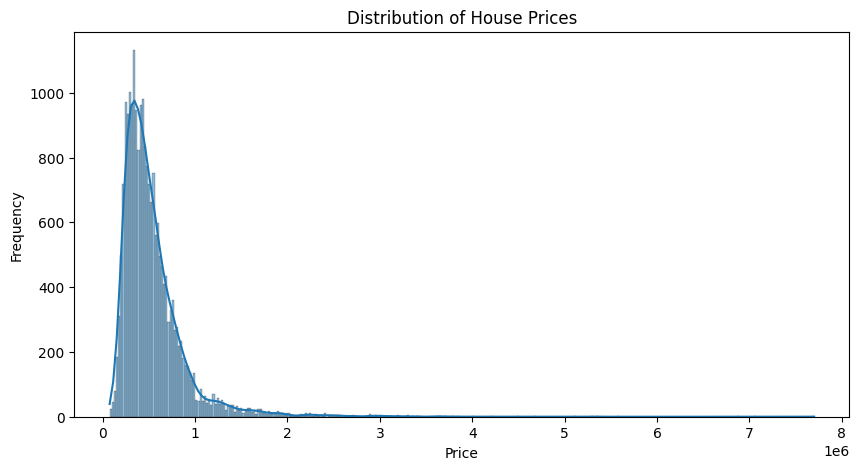

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

Based on the histogram above, the house price distribution is highly right-skewed (positively skewed).

Key findings:
- Most houses are concentrated in the lower-to-middle price range.
- Only a small number of houses have extremely high prices.
- There are several luxury or premium properties that create a long tail on the right side of the distribution.
- The dataset is not normally distributed.

Business Insights:
- The housing market is dominated by affordable to mid-range properties.
- High-priced properties exist but represent a small portion of the market.
- Premium houses may strongly influence average prices and model performance.

Modeling Implication:
- Because the target variable is skewed, future modeling may benefit from log transformation on the price variable to improve prediction stability and reduce outlier influence.

**2.3 Numerical Feature Analysis**

This step analyzes numerical variables individually to understand:
- distribution
- spread
- skewness
- unusual values
- potential outliers

In [16]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns


In [17]:
numerical_cols

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='object')

then we do visualizion on numerical feature distributions.

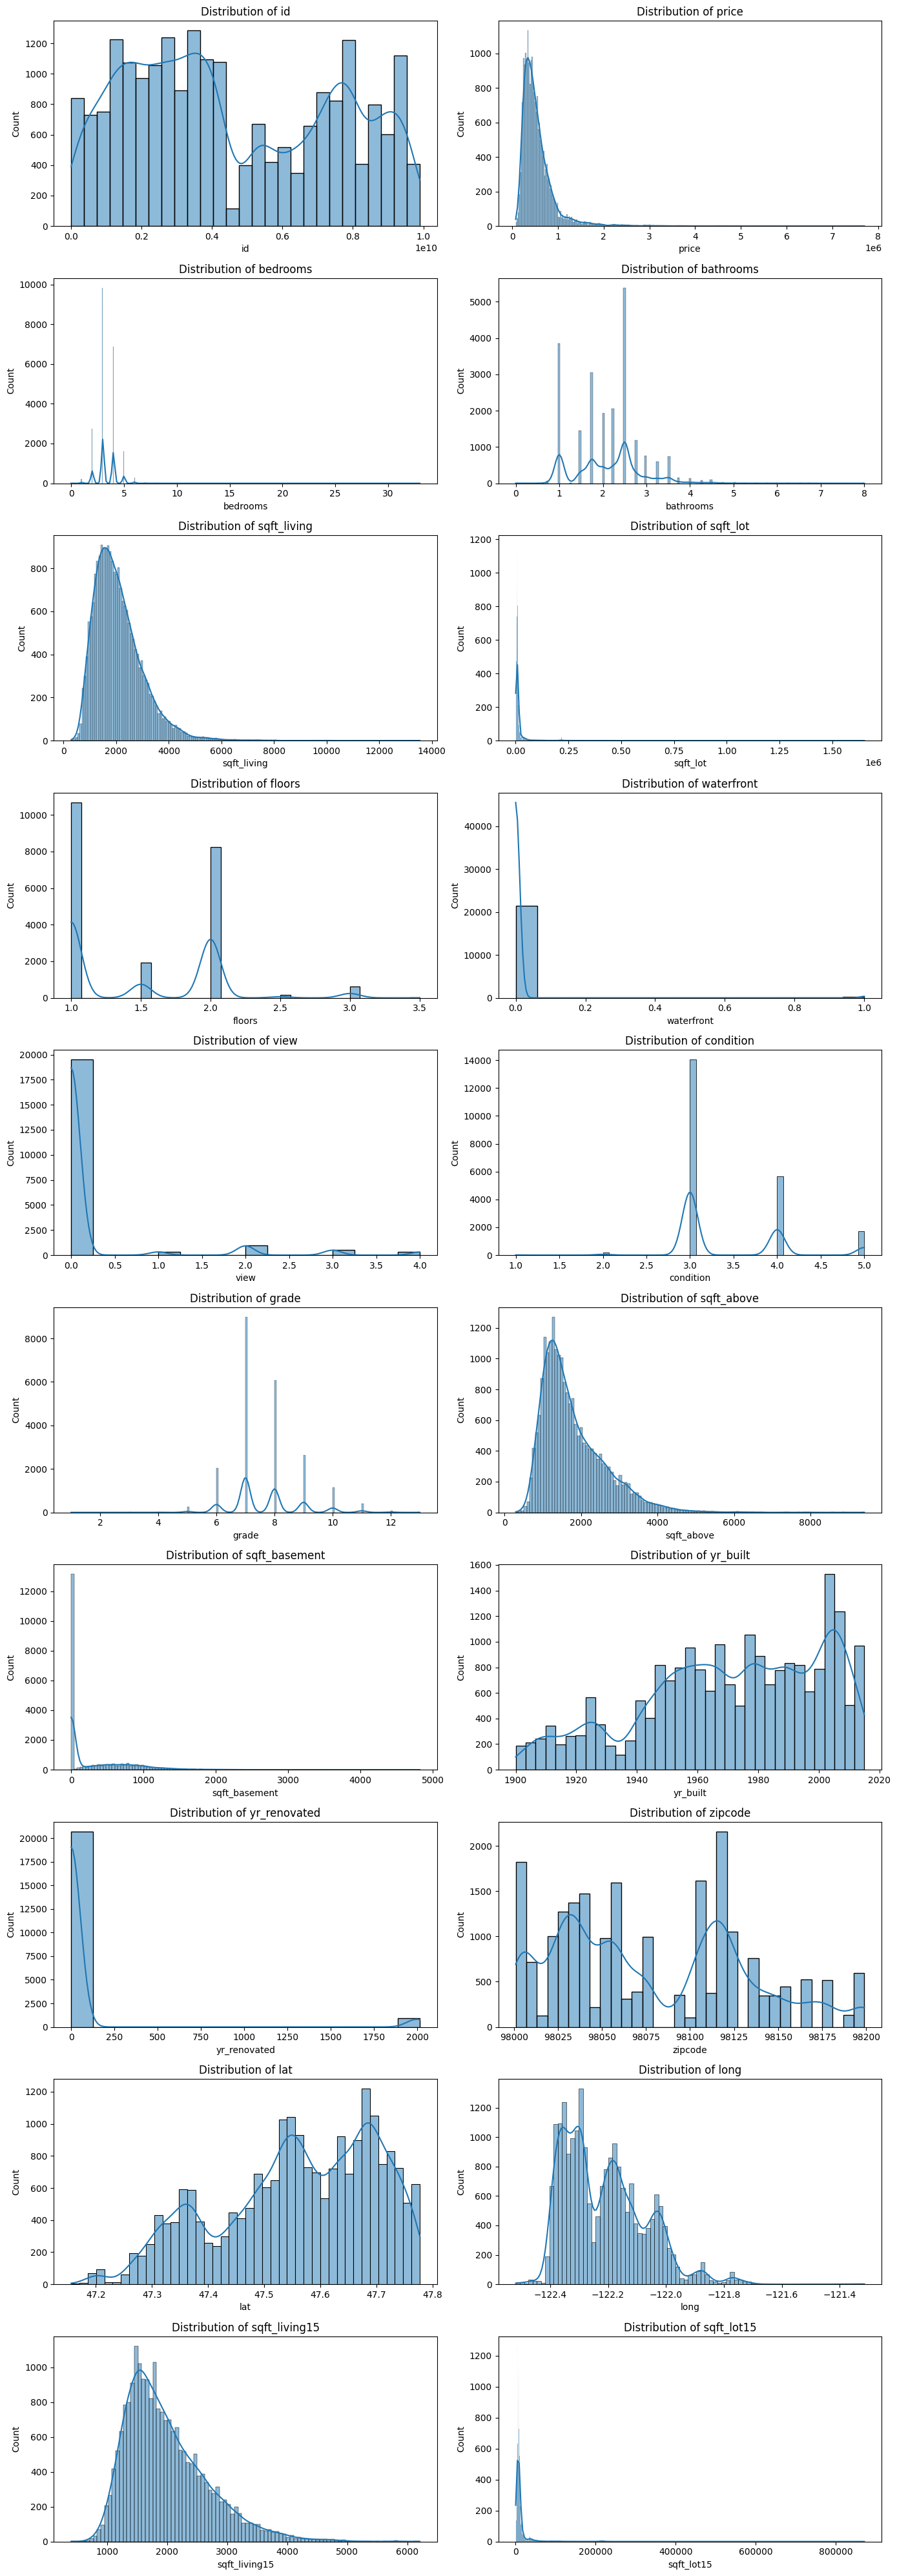

In [19]:
num_cols = len(numerical_cols)
rows = (num_cols + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(df[col], kde=True, ax=axes[i])

    axes[i].set_title(f'Distribution of {col}')
for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

| Finding | Business Insight |
|---|---|
| Mid-range houses dominate the market | Most properties are concentrated in affordable to middle-price segments, indicating stronger mass-market demand compared to luxury housing. |
| Large variation in house size | Features such as `sqft_living` and `sqft_above` suggest house size may strongly influence property valuation and pricing strategy. |
| Standard family-sized homes dominate | Most houses contain 3–4 bedrooms and 2–3 bathrooms, showing the market mainly targets family households. |
| Waterfront houses are rare | Waterfront properties are limited and likely positioned as premium or luxury assets with significantly higher value. |
| Most houses are in average-to-good condition | Condition scores cluster around 3–4, indicating relatively stable housing quality across the market. |
| Low renovation activity | Most properties were never renovated, meaning renovated houses may gain stronger market competitiveness and resale value. |
| Large outliers in lot size | Extremely large lot sizes may represent luxury estates, investment land, or potential anomalies requiring further investigation. |
| Location likely affects pricing | Latitude and longitude clustering suggests geographic area may strongly impact house demand and property prices. |

**2.4 Correlation Analysis**

Correlation analysis helps identify relationships between numerical variables.

Values closer to:
- 1,means strong positive relationship
- -1, strong negative relationship
- 0, means weak relationship

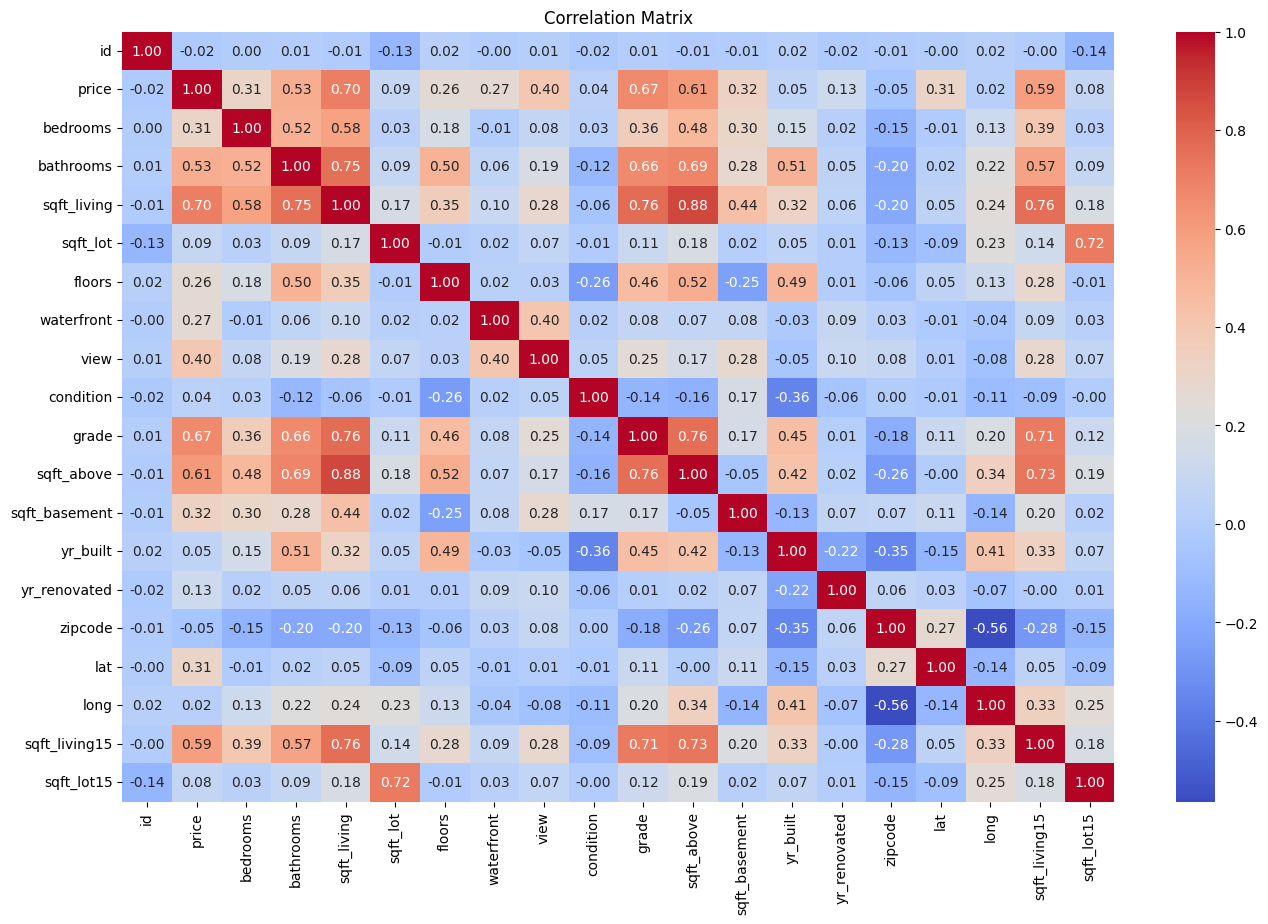

In [20]:
plt.figure(figsize=(16,10))

corr_matrix = df[numerical_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

| Finding | Business Insight |
|---|---|
| `sqft_living` has the strongest correlation with price (0.70) | House living area is one of the biggest drivers of property value. Larger living space generally leads to higher house prices. |
| `grade` strongly correlates with price (0.67) | Construction quality and overall house design significantly influence market valuation. Premium-quality houses tend to sell at much higher prices. |
| `sqft_above` highly correlates with price (0.61) | Above-ground living space contributes strongly to pricing decisions and perceived property value. |
| `bathrooms` moderately-to-strongly correlate with price (0.53) | Houses with more bathrooms are generally associated with higher market value and larger family demand. |
| `sqft_living15` correlates with price (0.59) | Neighborhood surrounding house sizes may influence pricing, indicating location and neighborhood quality matter. |
| `view` and `waterfront` positively affect price | Scenic value and waterfront access increase property desirability and premium pricing potential. |
| `condition` has weak correlation with price | House condition alone may not strongly determine pricing compared to size, location, and grade. |
| `zipcode` has weak negative relationship with price | Certain geographic areas may have lower average property values, but zipcode alone is not a strong predictor. |
| `sqft_lot` has weak correlation with price | Land size alone does not strongly determine house value; usable living space matters more. |
| `sqft_above` and `sqft_living` are highly correlated (0.88) | Potential multicollinearity exists, meaning both variables may carry similar information during modeling. |

**2.5 Top Features Correlated with Price**

In this step, we are going to identifies which variables have the strongest relationship with house prices.

**2.5.1 Sort Correlation with Price**

In [21]:
price_corr = corr_matrix['price'].sort_values(ascending=False)


In [22]:
price_corr

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525138
view,0.397293
sqft_basement,0.323816
bedrooms,0.308350
lat,0.307003


then we are going to vosualize the top correlation ones

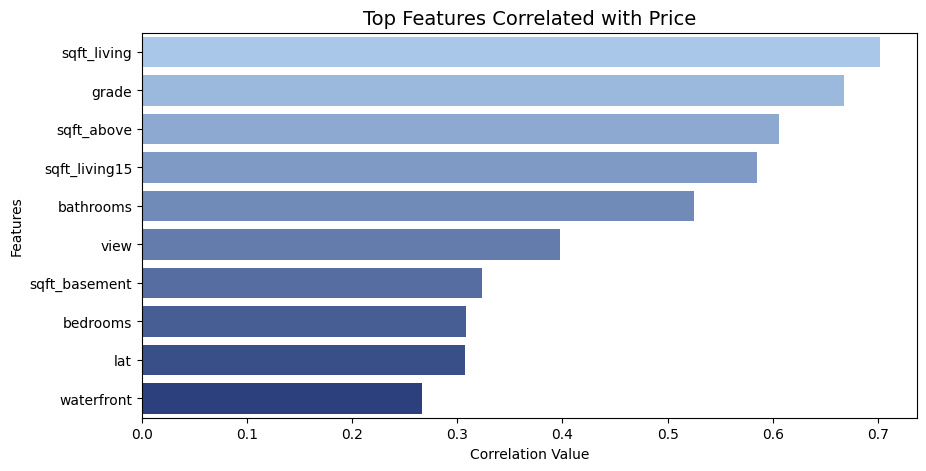

In [25]:
top_corr = price_corr[1:11]

plt.figure(figsize=(10,5))

colors = sns.color_palette("blend:#9EC6F3,#1E3A8A", len(top_corr))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    palette=colors
)

plt.title('Top Features Correlated with Price', fontsize=14)

plt.xlabel('Correlation Value')

plt.ylabel('Features')

plt.show()

| Top Feature | Business Interpretation |
|---|---|
| `sqft_living` | Living area is the strongest driver of house prices. Buyers highly value larger usable living space. |
| `grade` | Construction quality and house design significantly influence property valuation and selling price. |
| `sqft_above` | Above-ground living area strongly contributes to market value and buyer perception. |
| `sqft_living15` | Neighborhood quality and surrounding house sizes affect property pricing and perceived prestige. |
| `bathrooms` | Houses with more bathrooms tend to target higher-income or larger family segments. |
| `view` | Scenic views create premium pricing opportunities and increase property attractiveness. |
| `sqft_basement` | Additional functional space such as basements can increase house value. |
| `bedrooms` | More bedrooms generally increase value, but not as strongly as living area quality and size. |
| `lat` | Geographic location plays an important role in housing demand and pricing differences. |
| `waterfront` | Waterfront properties represent premium/luxury market segments with higher price potential. |

**2.6 Scatterplot Analysis (`Feature` vs `Price`)**

Scatterplots help visualize relationships between important features and house prices.

This helps identify:
- trends
- linear relationships
- clusters
- unusual observations

we started by select important features

In [26]:
important_features = [
    'sqft_living',
    'grade',
    'bathrooms',
    'sqft_above'
]

then create the scatterplots

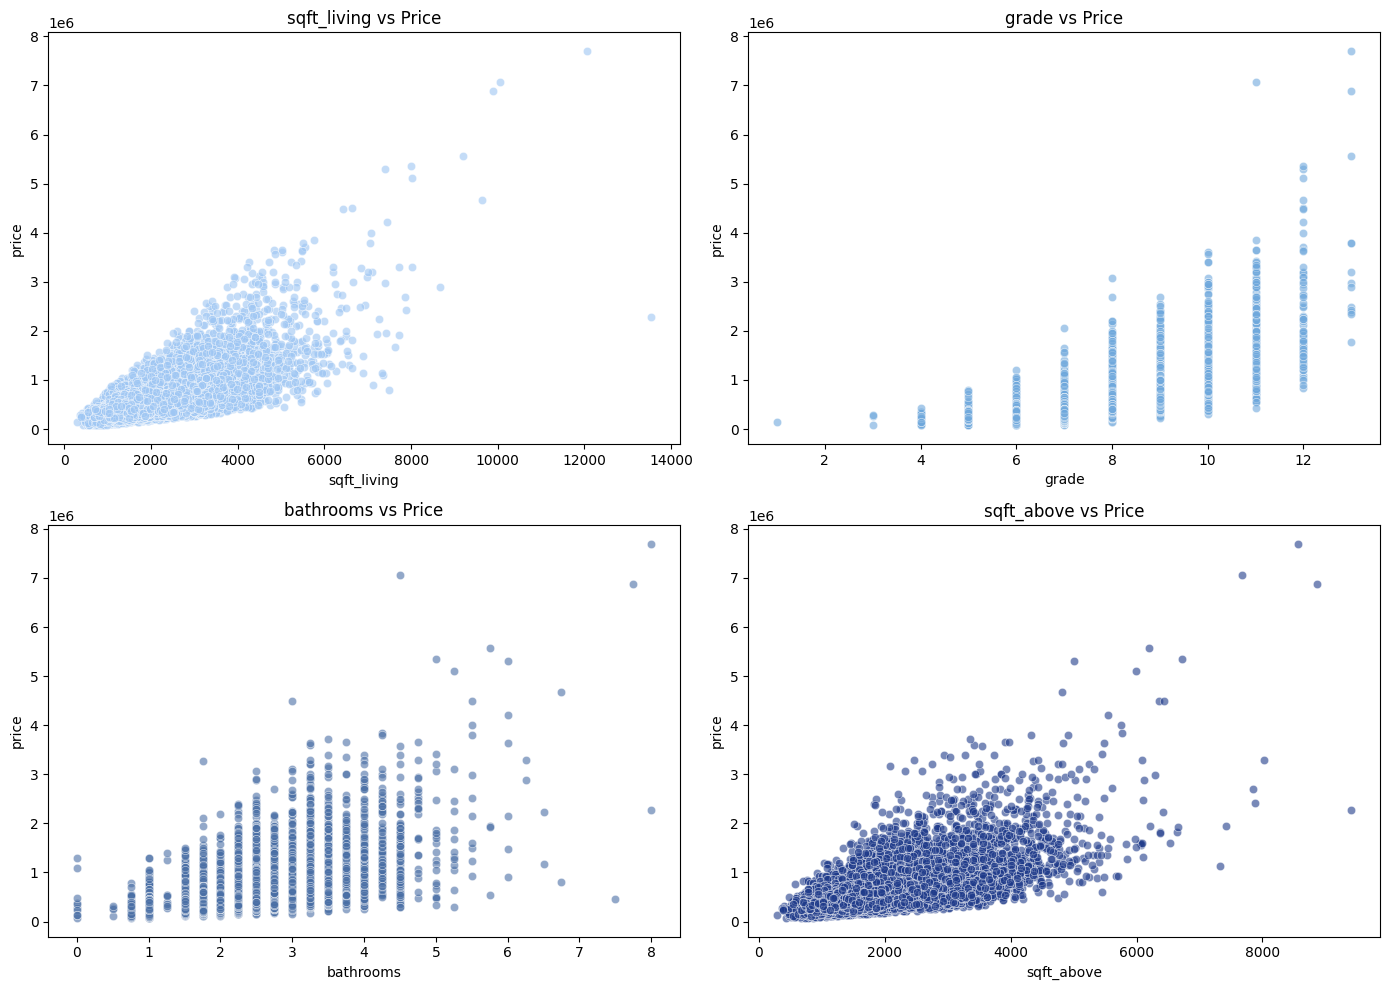

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

colors = [
    '#9EC6F3',
    '#6FA8DC',
    '#4A6FA5',
    '#1E3A8A'
]

for i, col in enumerate(important_features):

    sns.scatterplot(
        x=df[col],
        y=df['price'],
        ax=axes[i],
        color=colors[i],
        alpha=0.6
    )

    axes[i].set_title(f'{col} vs Price')

plt.tight_layout()

plt.show()

| Feature | Business Insight |
|---|---|
| `sqft_living` vs Price | Larger living areas generally lead to higher house prices, showing that usable space is a major value driver in the housing market. |
| `grade` vs Price | Higher construction/design quality consistently increases property value. Premium-grade houses dominate the luxury segment. |
| `bathrooms` vs Price | Houses with more bathrooms tend to have higher prices, especially for family-oriented and upscale properties. |
| `sqft_above` vs Price | Above-ground living space strongly affects pricing, indicating buyers value visible and functional living areas. |
| Presence of extreme high-price points | Several luxury properties create outliers in the market and may influence average pricing analysis. |
| Wider spread at larger house sizes | Bigger houses show more price variability, meaning luxury pricing depends not only on size but also on location, design, and amenities. |
| Clear upward trend across features | Most important housing features show positive relationships with price, supporting their importance for future predictive modeling. |

**2.7 Outlier Detection**

This step will helps identify extreme values that may:
* distort analysis
* affect model performance
* represent luxury properties or data errors

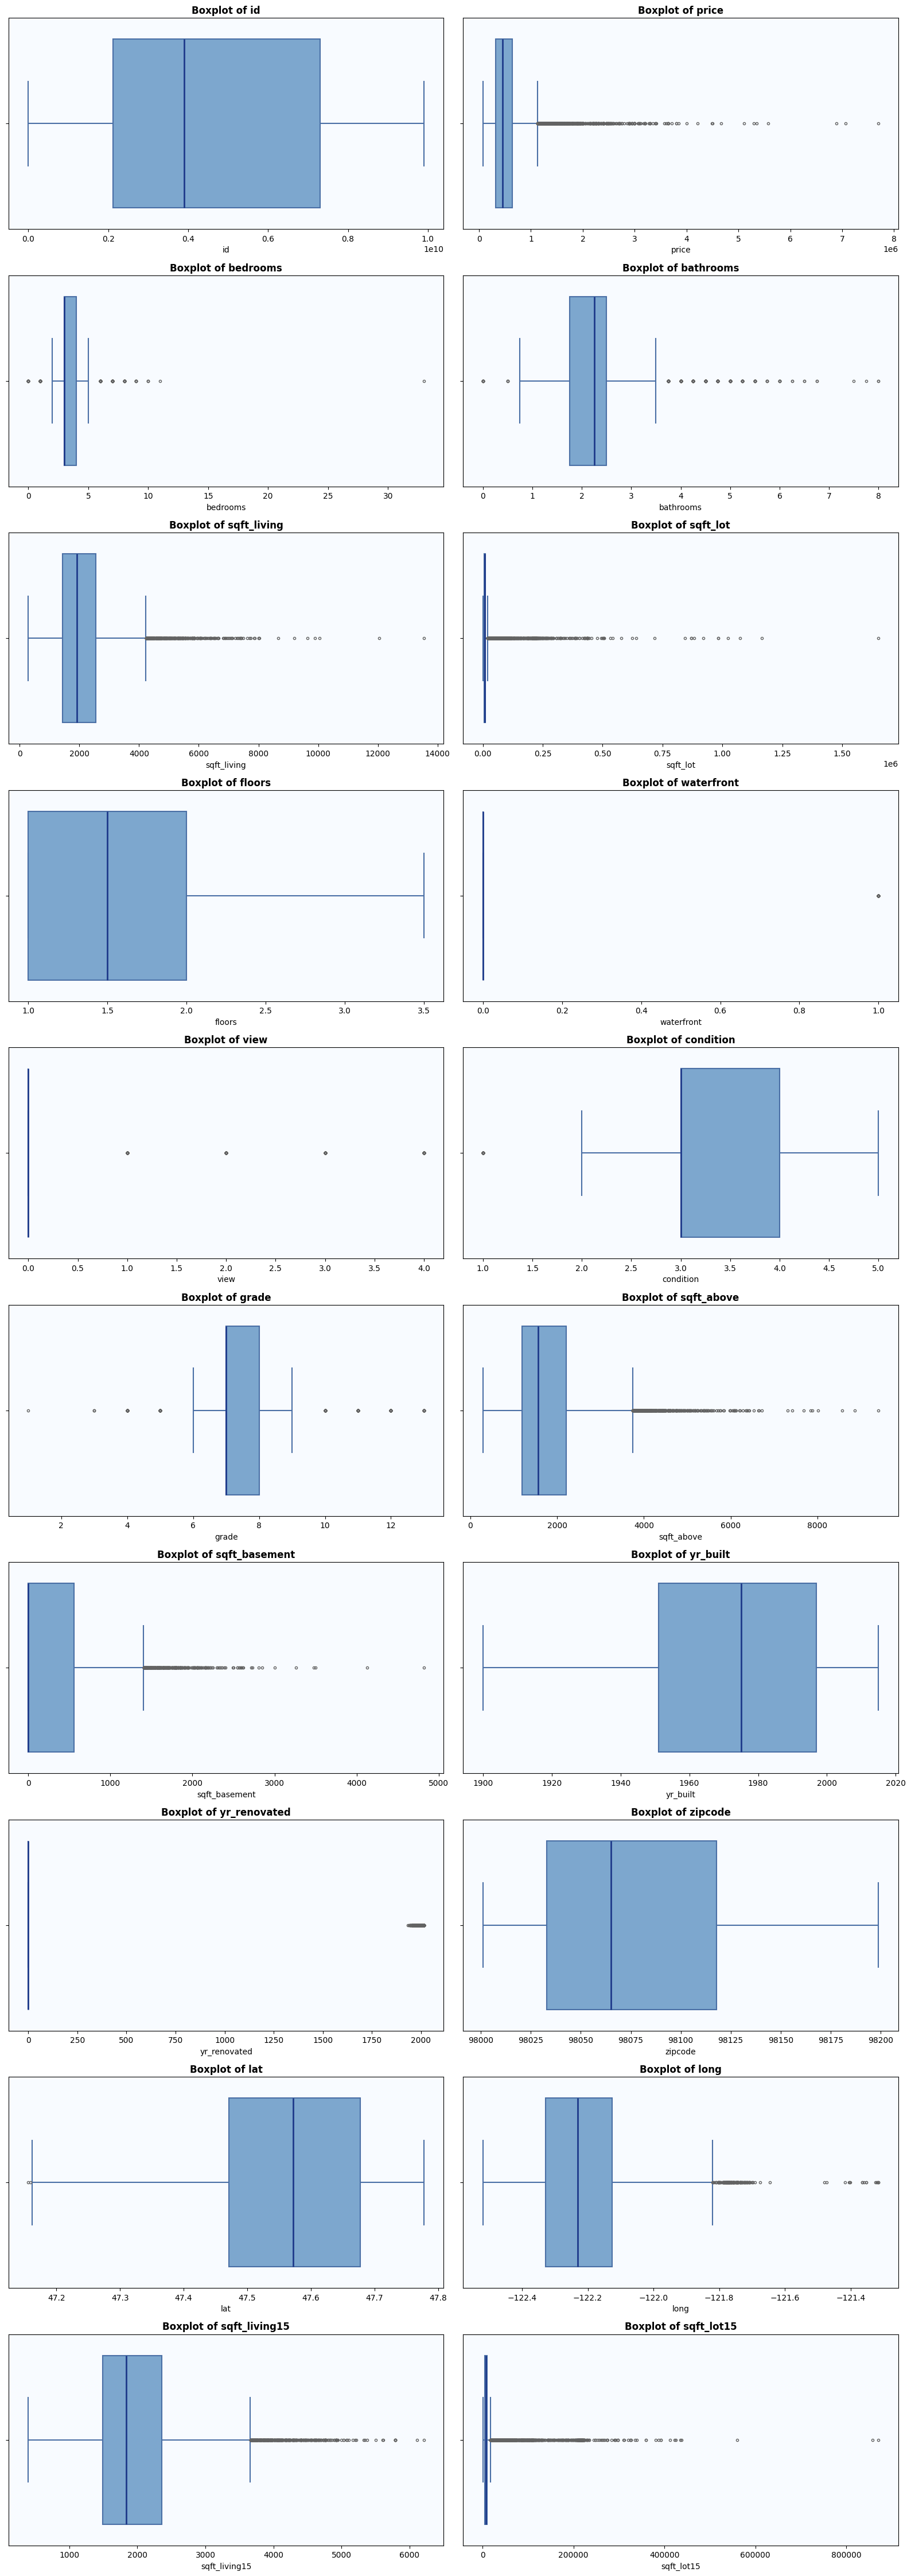

In [29]:
fig, axes = plt.subplots(rows, 2, figsize=(16, rows * 4.5))

axes = axes.flatten()

box_color = '#6FA8DC'
median_color = '#1E3A8A'

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        x=df[col],
        ax=axes[i],
        color=box_color,
        linewidth=1.5,
        fliersize=3,
        boxprops=dict(edgecolor='#4A6FA5'),
        whiskerprops=dict(color='#4A6FA5'),
        capprops=dict(color='#4A6FA5'),
        medianprops=dict(color=median_color, linewidth=2)
    )

    axes[i].set_title(
        f'Boxplot of {col}',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_facecolor('#F8FBFF')

for j in range(i + 1, len(axes)):

    fig.delaxes(axes[j])

fig.patch.set_facecolor('white')

plt.tight_layout()

plt.show()

| Finding | Business Interpretation |
|---|---|
| House prices contain many extreme outliers | The market includes luxury or premium properties with exceptionally high prices that may distort average market analysis. |
| `sqft_living`, `sqft_above`, and `sqft_basement` show large outliers | Some houses are significantly larger than typical properties, representing luxury homes or high-end residential segments. |
| `sqft_lot` and `sqft_lot15` contain very extreme values | Certain properties may include investment land, estate-sized lots, or potential data anomalies requiring validation. |
| Bedrooms and bathrooms have upper-end outliers | Houses with unusually high room counts likely target luxury buyers, large families, or commercial-style residential use. |
| Waterfront feature appears as a rare outlier | Waterfront houses are extremely limited and positioned as exclusive premium assets. |
| Most houses cluster within standard ranges | The majority of properties still fall within normal middle-market housing specifications. |
| Renovation data is heavily concentrated at zero | Most houses were never renovated, suggesting renovation could become a differentiation strategy in the market. |
| Geographic variables (`lat`, `long`) show limited spread | Properties are concentrated within certain regions, indicating localized market behavior and regional pricing clusters. |
| Grade and condition are relatively stable | Most houses have moderate-to-good quality standards, showing overall market consistency. |
| Outliers may affect machine learning models | Extreme values could bias prediction models and may require transformation, scaling, or outlier handling in preprocessing. |

#### **EDA Business Summary**

### 1. House Size is the Strongest Price Driver
Features such as:
- sqft_living
- sqft_above
- sqft_living15

show the strongest relationship with house prices. Larger usable living areas significantly increase property value.

### 2. Construction Quality Strongly Influences Value
Higher `grade` houses consistently achieve higher prices, indicating buyers are willing to pay premium prices for better design and construction quality.

### 3. Location Plays an Important Role
Features such as:
- latitude
- waterfront
- surrounding neighborhood size (`sqft_living15`)

suggest location and neighborhood quality strongly affect housing demand and pricing.

### 4. Luxury Segment Exists but is Limited
The dataset contains several luxury properties with:
- extremely large house sizes
- premium views
- waterfront access
- very high prices

However, most properties remain concentrated in the middle-market segment.

### 5. Standard Family Homes Dominate the Market
Most houses contain:
- 3–4 bedrooms
- 2–3 bathrooms
- 1–2 floors

showing the market is primarily designed for family households.

### 6. Renovation Could Create Competitive Advantage
Most properties were never renovated. Renovated homes may gain:
- higher selling prices
- stronger market attractiveness
- better buyer perception

### 7. Outliers Exist Across Multiple Variables
Extreme values appear in:
- price
- lot size
- living space
- bedrooms
- bathrooms

These outliers may represent luxury estates or potential anomalies and should be carefully handled during modeling.


# Phase 3 - Data Preprocessing & Feature Engineering

In this phase, we prepare the dataset before machine learning modeling.

The objectives are:
- clean and transform the data
- handle outliers if necessary
- prepare features for modeling
- improve model performance
- reduce potential bias and data leakage

**3.1 Drop Unnecessary Columns**
Some columns may not provide predictive value or may create noise during modeling.

For example:
- ID columns
- duplicated information
- irrelevant variables

In [30]:
df = df.drop('id', axis=1)

In [31]:
df.head() #to verify

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Raw date columns are difficult for machine learning models to interpret directly.

Feature engineering helps extract meaningful information such as:
- year
- month

This may improve model understanding of housing market trends over time.

**3.2.1 Convert Data to Datetime Format**

In [32]:
df['date'] = pd.to_datetime(df['date'])

**3.2.2 Extract Year and Month**

In [33]:
df['sale_year'] = df['date'].dt.year
df['sale_month'] = df['date'].dt.month

**3.2.3 Drop Original Date Column**

In [34]:
df = df.drop('date', axis=1)

lastly, (3.2.4) we verify the dataset

In [35]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2


In [38]:
df.columns

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month'],
      dtype='object')

then we are going to check the skewness (3.3.1)


In [40]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
skewness

,0
sqft_lot,13.060019
waterfront,11.385108
sqft_lot15,9.506743
yr_renovated,4.549493
price,4.024069
view,3.395750
bedrooms,1.974300
sqft_basement,1.577965
sqft_living,1.471555
sqft_above,1.446664


**3.3.2 Apply Log Transformation**

Log transformation is applied to highly skewed numerival variables (because our data is) to:
* reduce extreme value impact
* normalize distributions
* improve model stability
* improve predictive performance

In [41]:
log_cols = [
    'price',
    'sqft_lot',
    'sqft_lot15',
    'sqft_living',
    'sqft_above',
    'sqft_basement'
]

for col in log_cols:

    df[col] = np.log1p(df[col])

**3.3.3 Recheck Skewness**

In [42]:
df[log_cols].skew()

,0
price,0.428077
sqft_lot,0.962893
sqft_lot15,0.967255
sqft_living,-0.034727
sqft_above,0.254034
sqft_basement,0.484603


After log transformation, the skewness values decreased significantly.

Key improvements:
- `price`: from 4.02 → 0.43
- `sqft_lot`: from 13.06 → 0.96
- `sqft_living`: from 1.47 → -0.03

This indicates the distributions are now much more balanced and closer to normal distribution.

Benefits for modeling:
- reduces extreme value influence
- improves model stability
- improves prediction quality
- helps machine learning algorithms learn patterns more effectively

**3.4 Define Features (`X`) and Target (`y`)**

Before modeling, we separate:
- X → independent variables/features
- y → target variable

The target variable is the value we want to predict.

**3.4.1 Define `X` and `y`**

In [43]:
X = df.drop('price', axis=1)
y = df['price']

In [44]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21613, 20)
y shape: (21613,)


**3.5 Train-Test Split**

In [45]:
from sklearn.model_selection import train_test_split

3.5.1 Split Dataset

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

3.5.2 Verfiy Shapes

In [47]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (17290, 20)
X_test: (4323, 20)
y_train: (17290,)
y_test: (4323,)


After this, we are going to **3.6 Feature Scaling**.

As some features have very different scales. If we don't do scaling we are going:
* large-value features may dominate the model
* model performance can become unstable.
So, by scaling the feature helps normalize feature ranges.

In [48]:
from sklearn.preprocessing import StandardScaler

In [49]:
scaler = StandardScaler()

In [50]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print("X_train_scaled:", X_train_scaled.shape)

print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (17290, 20)
X_test_scaled: (4323, 20)


The feature scaling process was successfully applied.

Key points:
- The number of rows and columns remains unchanged.
- Only the feature values were standardized.
- Features now have more balanced scales for machine learning algorithms.

Benefits:
- improves model stability
- prevents large-scale variables from dominating
- helps algorithms learn patterns more effectively

# Phase 4 - Machine Learning Modeling

In this phase, we will build machine learning models to predict house prices.

Objectives:
- train predictive models
- compare model performance
- identify the best-performing model
- evaluate prediction quality

**4.1 Import Machine Learning Models**

We are going to import multiple regression models to identify the best-performing model for house prediction.

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

**4.1.2 import evaluatin metrics**

In [53]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

**4.2 Train Baseline Models**

Baseline models are initial machine learning models trained without hyperparameter tuning.

The purpose is to:
- compare model performance
- identify strengths and weaknesses
- establish initial benchmark results

4.2.1 Initialize Models

In [54]:
lr_model = LinearRegression()
dt_model = DecisionTreeRegressor(random_state=42)
rf_model = RandomForestRegressor(random_state=42)

4.2.2 Train Models

In [55]:
# linear reg
lr_model.fit(X_train_scaled, y_train)

# DT
dt_model.fit(X_train_scaled, y_train)

# RF
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

4.2.3 Generate Predictions

In [56]:
lr_pred = lr_model.predict(X_test_scaled)
dt_pred = dt_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)

**4.3 Evaluate Model Performance**

Model evaluation helps measure prediction performance and compare models objectively.

Evaluation metrics:
- MAE → average prediction error
- RMSE → prediction error sensitivity to large mistakes
- R² Score → how well the model explains target variation

4.3.1 Create Evaluation Function

In [57]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

4.3.2 Evaluate All Models

In [58]:
lr_results = evaluate_model(y_test, lr_pred, 'Linear Regression')

dt_results = evaluate_model(y_test, dt_pred, 'Decision Tree')

rf_results = evaluate_model(y_test, rf_pred, 'Random Forest')

4.3.3 create comparison table

In [59]:
results_df = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results
])

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.193098,0.251663,0.777799
1,Decision Tree,0.177922,0.248734,0.782940
2,Random Forest,0.125957,0.176848,0.890274


| Model | Interpretation |
|---|---|
| Linear Regression | Performs reasonably well as a baseline model, explaining around 77.8% of house price variation. However, prediction errors are still relatively higher compared to ensemble models. |
| Decision Tree | Slightly improves performance over Linear Regression, indicating non-linear relationships exist within the housing dataset. |
| Random Forest | Achieves the best overall performance with the lowest MAE and RMSE and the highest R² Score (89%). This indicates Random Forest captures housing price patterns more effectively than the other models. |

#### Insights
- Random Forest is currently the best-performing model.
- The model explains approximately 89% of house price variability.
- Lower MAE and RMSE indicate more accurate predictions and fewer large prediction errors.
- Housing prices likely contain complex non-linear relationships better captured by ensemble tree models.

- MAE (Mean Absolute Error):
  Average prediction error.
  Lower is better.

- RMSE (Root Mean Squared Error):
  Penalizes large prediction mistakes more heavily.
  Lower is better.

- R² Score:
  Measures how much variation the model can explain.
  Closer to 1 is better.

**4.4 Visualize Model Comparison**

4.4.1 Visualize R² Score Comparison

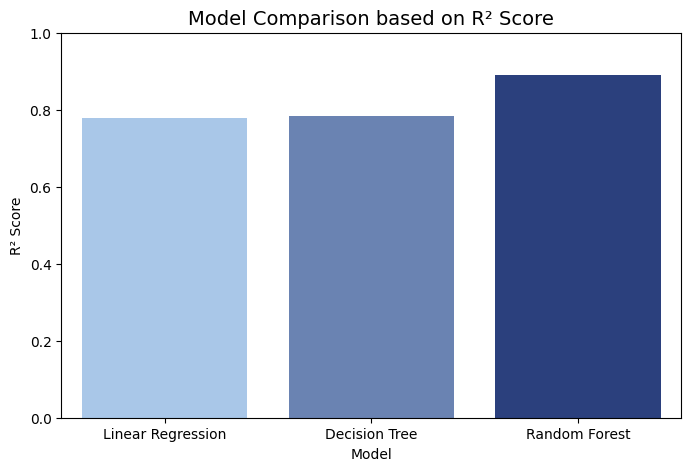

In [60]:
plt.figure(figsize=(8,5))

colors = sns.color_palette(
    "blend:#9EC6F3,#1E3A8A",
    len(results_df)
)

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score',
    palette=colors
)

plt.title('Model Comparison based on R² Score', fontsize=14)

plt.ylim(0,1)

plt.ylabel('R² Score')

plt.xlabel('Model')

plt.show()

4.4.2 Visualize RMSE Comparison

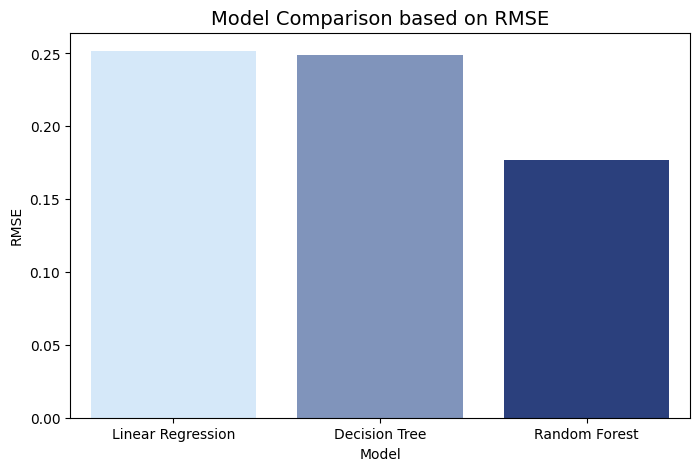

In [61]:
plt.figure(figsize=(8,5))

colors = sns.color_palette(
    "blend:#CFE8FF,#1E3A8A",
    len(results_df)
)

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE',
    palette=colors
)

plt.title('Model Comparison based on RMSE', fontsize=14)

plt.ylabel('RMSE')

plt.xlabel('Model')

plt.show()

| Visualization | Interpretation |
|---|---|
| R² Score Comparison | Random Forest achieves the highest R² Score, meaning it explains house price variation better than Linear Regression and Decision Tree models. |
| RMSE Comparison | Random Forest has the lowest RMSE, indicating smaller prediction errors and better prediction accuracy. |
| Linear Regression Performance | Performs adequately as a baseline model but struggles to capture more complex housing price patterns. |
| Decision Tree Performance | Slight improvement over Linear Regression, suggesting the dataset contains non-linear relationships. |
| Random Forest Dominance | Ensemble learning significantly improves predictive performance by combining multiple decision trees. |

## Overall Conclusion
- Random Forest is the best-performing model among the three tested models.
- The model provides:
  - highest explanatory power
  - lowest prediction error
  - strongest overall predictive capability
- Housing price prediction benefits from non-linear and ensemble-based machine learning approaches.

**4.5 Actual vs Predicted**

Actual vs Predicted visualization helps evaluate how closely model predictions match actual house prices.

A good model will produce predictions that closely follow the diagonal trend line.

4.5.1 Create Actual vs Predicted Plot (Random Forest)

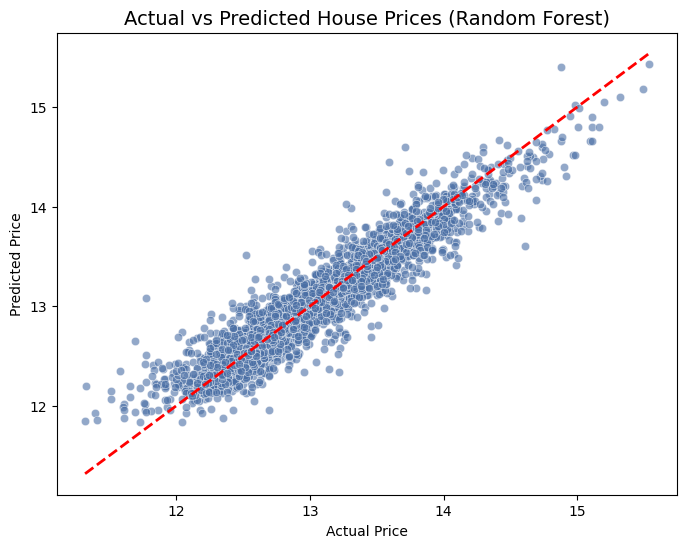

In [63]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=rf_pred,
    color='#4A6FA5',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    linewidth=2
)

plt.title('Actual vs Predicted House Prices (Random Forest)', fontsize=14)

plt.xlabel('Actual Price')

plt.ylabel('Predicted Price')

plt.show()

| Observation | Interpretation |
|---|---|
| Most points are close to the diagonal line | The Random Forest model predicts house prices quite accurately. |
| Strong linear pattern between actual and predicted values | The model successfully captures the relationship between housing features and prices. |
| Small spread around the diagonal line | Prediction errors are relatively low and stable across most observations. |
| Some deviations exist at higher prices | The model still struggles slightly when predicting extremely expensive houses, likely due to luxury-property outliers. |
| No major random scattering pattern | Indicates the model generalizes well and is not behaving randomly. |

**Overall Conclusion**
The Random Forest model demonstrates strong predictive performance and good generalization capability.

The close alignment between actual and predicted values supports the earlier evaluation metrics showing:
- high R² Score
- low RMSE
- strong overall model accuracy

**4.6 Feature Importance Analysis**

After knowing Random Forest is the best model, we should understand: "which features influence house prices the most?"

This is important because:
* makes model explainable
* gives business insight
* helps investors/property stakeholders understand key value drivers.

4.6.1 Extract Feature Importance

In [64]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,grade,0.343105
14,lat,0.292778
2,sqft_living,0.176701
15,long,0.044714
16,sqft_living15,0.025997
11,yr_built,0.021476
3,sqft_lot,0.015525
9,sqft_above,0.014134
17,sqft_lot15,0.014014
13,zipcode,0.010566


4.6.2 Visualize Top 10 Important Features

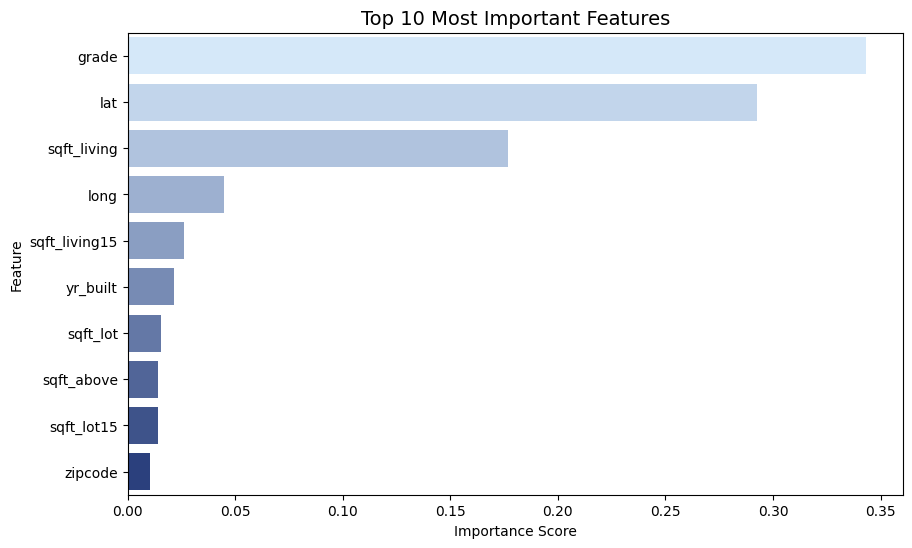

In [65]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

colors = sns.color_palette(
    "blend:#CFE8FF,#1E3A8A",
    len(top_features)
)

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature',
    palette=colors
)

plt.title(
    'Top 10 Most Important Features',
    fontsize=14
)

plt.xlabel('Importance Score')

plt.ylabel('Feature')

plt.show()

| Feature | Business Interpretation |
|---|---|
| `grade` | Construction quality and house design are the strongest drivers of house prices. Higher-grade houses command significantly higher market value. |
| `lat` | Geographic location heavily influences property pricing, indicating strong regional demand differences. |
| `sqft_living` | Usable living area remains one of the most important pricing factors for buyers. |
| `long` | Longitude also contributes to pricing, reinforcing the importance of neighborhood and location. |
| `sqft_living15` | Surrounding neighborhood house size influences perceived property value and market positioning. |
| `yr_built` | Newer houses generally provide higher value due to modern construction and lower maintenance expectations. |
| `sqft_lot` | Land size contributes to pricing but is less influential than actual living space. |
| `sqft_above` | Above-ground usable space positively affects house valuation and buyer appeal. |
| `sqft_lot15` | Neighborhood land characteristics also influence market perception and pricing. |
| `zipcode` | Area segmentation and district differences contribute to housing value variation. |

**Key Insight**
The model indicates that:
- quality
- location
- living space

are the three strongest drivers of house prices.

This suggests buyers prioritize:
- premium construction quality
- strategic neighborhoods
- functional living space

more than simply large land size alone.

### **4.7 Final Model Conclusion**

#### Model Performance Summary

Three machine learning models were evaluated:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

Among all tested models, Random Forest achieved the best predictive performance.

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Linear Regression | 0.193 | 0.252 | 0.778 |
| Decision Tree | 0.178 | 0.249 | 0.783 |
| Random Forest | 0.126 | 0.177 | 0.890 |

---

#### Best Model: Random Forest

Random Forest outperformed the other models by:
- achieving the highest R² Score
- producing the lowest prediction errors
- capturing complex non-linear relationships within the housing dataset

The model successfully explains approximately 89% of house price variation.

---

#### Key Drivers of House Prices

Based on feature importance analysis, the strongest factors influencing house prices are:
1. House grade/quality
2. Geographic location
3. Living area size
4. Neighborhood characteristics
5. Property age

This indicates buyers prioritize:
- construction quality
- strategic location
- functional living space

more heavily than land size alone.

---

#### Overall Findings

The housing market shows:
- strong influence from location and quality
- dominance of middle-market family housing
- presence of luxury-property outliers
- non-linear pricing behavior

This explains why ensemble machine learning methods such as Random Forest perform better than simpler linear models.

---

#### Conclusion

The Random Forest model demonstrates strong predictive capability and can be effectively used for:
- house price estimation
- property valuation support
- housing market analysis
- real estate investment insights

What I learned is;

to identify the root cause of declining transaction volume in a property company, I would apply a slice-and-dice analysis approach by breaking down the transaction data into multiple business dimensions to identify where the decline is concentrated.

The first dimension I would analyze is location. Property demand is highly dependent on geographic factors, so I would compare transaction trends across different regions or zip codes. A heatmap or regional sales trend visualization could help identify whether the decline is occurring only in specific areas or across the entire market. If only certain locations are underperforming, possible causes may include declining neighborhood attractiveness, oversupply, accessibility issues, or shifting customer preferences.

The second dimension would be price segment. I would divide properties into categories such as affordable, middle-market, and premium housing, then compare transaction volume trends for each segment over time. A line chart or segmented bar chart would help reveal whether the decline is concentrated in a specific pricing tier. For example, a decline in premium-property transactions could indicate weaker purchasing power, tighter financing conditions, or changing economic sentiment among upper-income buyers.

The third dimension would be time period. Analyzing transactions monthly or quarterly would help determine whether the decline is seasonal, temporary, or part of a longer-term trend. Time-series visualization could reveal patterns such as sudden drops after policy changes, interest rate increases, or economic uncertainty.

In addition, I would also evaluate inventory levels and marketing channels. High inventory combined with declining transactions may indicate weak demand or pricing mismatches, while lower conversion rates from marketing campaigns may suggest ineffective targeting or poor lead quality.

To validate hypotheses, I would rely on:
- transaction trend analysis
- segmentation comparisons
- geographic heatmaps
- conversion funnel metrics
- inventory turnover analysis
- time-series visualizations

By combining these dimensions, the company can identify whether the transaction decline is driven primarily by location-specific issues, pricing strategy, market conditions, inventory imbalance, or marketing effectiveness.

then we save to joblib just in case, in the future we are going to make the streamlit.

In [66]:
import joblib

In [67]:
joblib.dump(rf_model, 'random_forest_model.pkl')

['random_forest_model.pkl']

In [68]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [69]:
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

['feature_columns.pkl']

In [70]:
import os

os.listdir()

['.config',
 'housedata.csv',
 'random_forest_model.pkl',
 'scaler.pkl',
 'feature_columns.pkl',
 'sample_data']